In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("titanic.csv")
df.head()
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [3]:
x = df[["Pclass", "Age", "Fare"]]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [5]:
from sklearn.cluster import KMeans

In [6]:
model = KMeans(n_clusters=3, random_state=42)

In [7]:
model.fit(x_scaled)

KMeans(n_clusters=3, random_state=42)

In [8]:
clusters = model.labels_

print(clusters)

[0 1 2 1 2 2 1 0 2 0 0 1 0 2 0 2 0 2 2 2 2 2 0 1 0 2 2 1 2 2 1 1 2 2 1 1 2
 0 0 0 2 2 2 0 0 2 2 2 2 0 0 0 1 2 1 1 0 2 0 0 0 1 1 0 1 2 2 0 0 2 2 0 0 2
 2 2 2 2 0 2 0 2 2 1 0 2 0 2 1 2 2 0 1 2 2 2 1 1 2 2 2 2 1 2 2 2 0 2 2 2 1
 0 0 0 0 0 2 2 1 0 0 2 2 2 1 0 2 2 2 2 2 0 2 2 2 2 1 1 0 1 2 0 2 0 0 0 2 0
 2 2 2 1 2 2 2 1 0 2 2 2 2 2 2 0 0 0 1 2 1 2 1 0 0 0 1 0 2 1 2 2 2 2 0 0 0
 1 2 1 2 2 2 0 0 0 1 1 2 2 2 2 2 2 2 2 0 0 2 2 0 1 2 2 0 2 2 1 2 2 1 2 0 2
 2 2 1 0 0 0 0 2 1 2 2 0 2 2 2 0 0 2 2 2 2 0 2 1 2 2 1 2 2 2 1 2 2 2 1 1 1
 2 2 0 1 1 2 2 0 2 1 1 1 2 2 1 2 1 2 2 0 2 2 2 0 0 1 2 2 0 2 0 1 1 2 2 2 1
 0 1 1 1 2 2 0 2 2 1 1 1 2 1 1 1 2 2 2 2 2 2 1 1 0 2 2 0 2 1 2 2 2 1 2 1 1
 0 1 2 1 1 2 1 0 1 2 2 2 2 2 2 0 2 0 1 0 2 2 2 1 2 2 2 2 2 2 2 2 2 1 2 2 1
 1 0 0 1 0 1 0 1 0 0 1 0 2 1 2 0 0 2 2 0 1 0 2 1 2 0 2 2 2 2 2 2 0 2 0 2 2
 0 0 2 2 2 1 2 2 2 2 0 2 0 2 0 2 2 0 2 2 0 2 2 1 2 2 0 1 1 0 2 1 2 2 0 2 2
 2 1 0 1 0 1 2 2 1 1 2 2 1 1 2 2 1 2 1 2 2 2 2 1 2 0 2 2 2 2 0 1 2 2 0 0 0
 2 2 2 1 2 1 1 2 0 2 0 1 

In [9]:
df["Cluster"] = clusters
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cluster
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,2


In [10]:
import matplotlib.pyplot as plt

In [11]:
wcss = []

In [12]:
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)

    model.fit(x_scaled)

    wcss.append(model.inertia_)

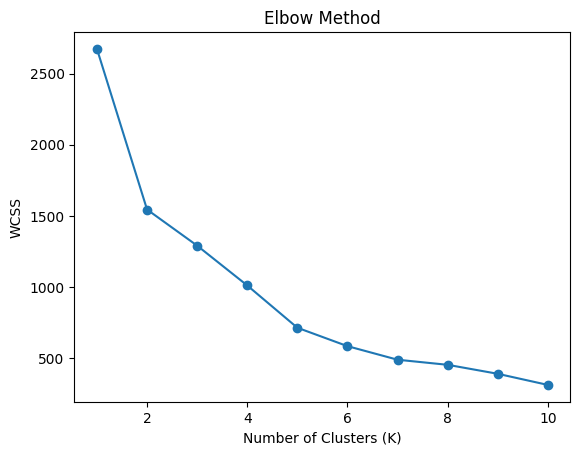

In [13]:
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()